In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

pd.options.display.max_columns = None
df = pd.read_csv("/content/drive/MyDrive/Dataset/cybersecurity_intrusion_data.csv")

In [3]:
print(df.head())

   Unnamed: 0 session_id  network_packet_size protocol_type network_segment  \
0           0  SID_00001                  599           TCP               A   
1           1  SID_00002                  472           TCP               B   
2           2  SID_00003                  629           TCP               C   
3           3  SID_00004                  804           UDP               C   
4           4  SID_00005                  453           TCP               A   

   login_attempts  session_duration encryption_used  ip_reputation_score  \
0               4        492.983263             DES             0.606818   
1               3       1557.996461             DES             0.301569   
2               3         75.044262             DES             0.739164   
3               4        601.248835             DES             0.123267   
4               5        532.540888             AES             0.054874   

   failed_logins browser_type  unusual_time_access  attack_detected 

In [4]:
df = df.drop('Unnamed: 0', axis=1)

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   network_segment      9537 non-null   object 
 4   login_attempts       9537 non-null   int64  
 5   session_duration     9537 non-null   float64
 6   encryption_used      7571 non-null   object 
 7   ip_reputation_score  9537 non-null   float64
 8   failed_logins        9537 non-null   int64  
 9   browser_type         9537 non-null   object 
 10  unusual_time_access  9537 non-null   int64  
 11  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 894.2+ KB
None


In [6]:
baris_duplikat = df[df.duplicated()]
print("jumlah data duplikat adalah", baris_duplikat.shape)

jumlah data duplikat adalah (0, 12)


In [7]:
print("Jumlah data kosong adalah : \n", df.isnull().sum())

Jumlah data kosong adalah : 
 session_id                0
network_packet_size       0
protocol_type             0
network_segment           0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64


In [8]:
df['encryption_used'] = df['encryption_used'].fillna('AES')
print("Jumlah data kosong adalah : \n", df.isnull().sum())

Jumlah data kosong adalah : 
 session_id             0
network_packet_size    0
protocol_type          0
network_segment        0
login_attempts         0
session_duration       0
encryption_used        0
ip_reputation_score    0
failed_logins          0
browser_type           0
unusual_time_access    0
attack_detected        0
dtype: int64


In [9]:
print(df.describe())

       network_packet_size  login_attempts  session_duration  \
count          9537.000000     9537.000000       9537.000000   
mean            500.430639        4.032086        792.745312   
std             198.379364        1.963012        786.560144   
min              64.000000        1.000000          0.500000   
25%             365.000000        3.000000        231.953006   
50%             499.000000        4.000000        556.277457   
75%             635.000000        5.000000       1105.380602   
max            1285.000000       13.000000       7190.392213   

       ip_reputation_score  failed_logins  unusual_time_access  \
count          9537.000000    9537.000000          9537.000000   
mean              0.331338       1.517773             0.149942   
std               0.177175       1.033988             0.357034   
min               0.002497       0.000000             0.000000   
25%               0.191946       1.000000             0.000000   
50%               0.314778 

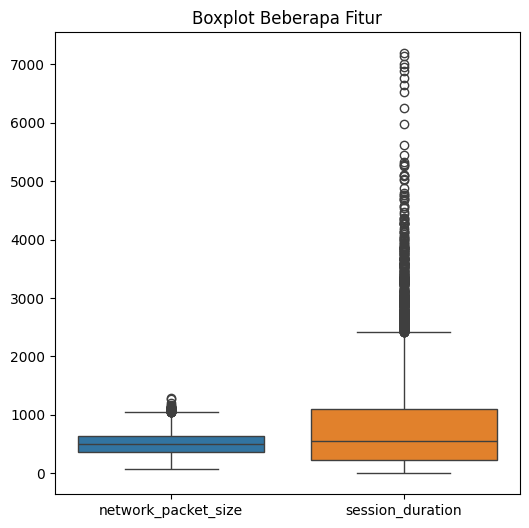

In [10]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df[['network_packet_size','session_duration']])
plt.title("Boxplot Beberapa Fitur")
plt.show()

In [11]:
Q1s = df['session_duration'].quantile(0.25)
Q3s = df['session_duration'].quantile(0.75)
IQRs = Q3s - Q1s
lower_bounds = Q1s - 1.5 * IQRs
upper_bounds = Q3s + 1.5 * IQRs
outlierss = df[(df['session_duration'] < lower_bounds) | (df['session_duration'] > upper_bounds)]
outs = outlierss.value_counts()
print(f"Jumlah outlier : {outs}")
print(f'IQR : {IQRs}')
print(f'Lower Bound : {lower_bounds} ')
print(f'Upper Bound : {upper_bounds}')

Jumlah outlier : session_id  network_packet_size  protocol_type  network_segment  login_attempts  session_duration  encryption_used  ip_reputation_score  failed_logins  browser_type  unusual_time_access  attack_detected
SID_09530   469                  TCP            B                1               2487.078455       AES              0.497153             0              Chrome        0                    0                  1
SID_00028   575                  TCP            B                3               3286.221728       DES              0.420471             0              Chrome        0                    0                  1
SID_09197   807                  TCP            A                5               3596.076380       DES              0.154645             0              Firefox       0                    0                  1
SID_09184   566                  TCP            A                1               2633.545063       AES              0.091223             2              Chro

In [12]:
Q1n = df['network_packet_size'].quantile(0.25)
Q3n = df['network_packet_size'].quantile(0.75)
IQRn = Q3n - Q1n
lower_boundn = Q1n - 1.5 * IQRn
upper_boundn = Q3n + 1.5 * IQRn
outliersn = df[(df['network_packet_size'] < lower_boundn) | (df['network_packet_size'] > upper_boundn)]
outn = outliersn.value_counts()
print(f"Jumlah outlier : {outn}")
print(f'IQR : {IQRn}')
print(f'Lower Bound : {lower_boundn} ')
print(f'Upper Bound : {upper_boundn}')

Jumlah outlier : session_id  network_packet_size  protocol_type  network_segment  login_attempts  session_duration  encryption_used  ip_reputation_score  failed_logins  browser_type  unusual_time_access  attack_detected
SID_00180   1044                 TCP            B                4               510.984574        AES              0.500439             2              Edge          0                    0                  1
SID_00210   1270                 TCP            C                5               1031.523815       DES              0.774616             1              Chrome        0                    1                  1
SID_00479   1115                 TCP            B                1               1012.621059       DES              0.457402             1              Edge          0                    0                  1
SID_01616   1138                 TCP            B                6               144.380252        DES              0.462796             3              Edge

encryption_used
AES    6672
DES    2865
Name: count, dtype: int64


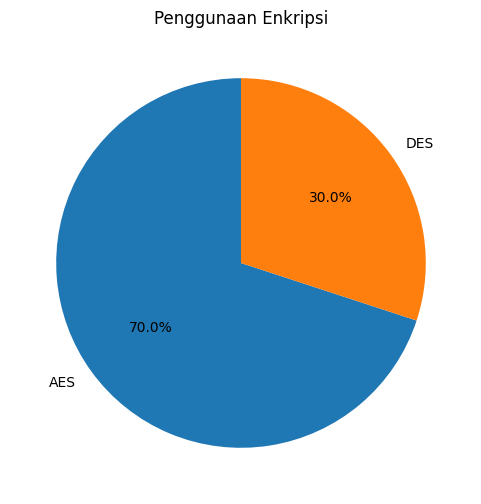

In [13]:
A = df["encryption_used"].value_counts()
print(A)
plt.figure(figsize=(6,6))
plt.pie(A, labels=A.index, autopct='%1.1f%%', startangle=90)
plt.title("Penggunaan Enkripsi")
plt.show()

browser_type
Chrome     5137
Firefox    1944
Edge       1469
Unknown     502
Safari      485
Name: count, dtype: int64


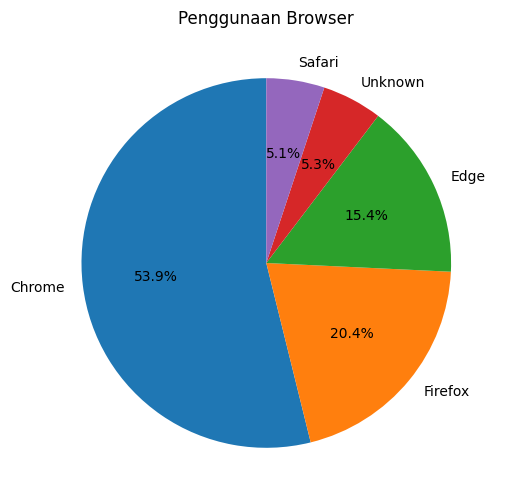

In [14]:
B = df["browser_type"].value_counts()
print(B)
plt.figure(figsize=(6,6))
plt.pie(B, labels=B.index, autopct='%1.1f%%', startangle=90)
plt.title("Penggunaan Browser")
plt.show()

protocol_type
TCP     6624
UDP     2406
ICMP     507
Name: count, dtype: int64


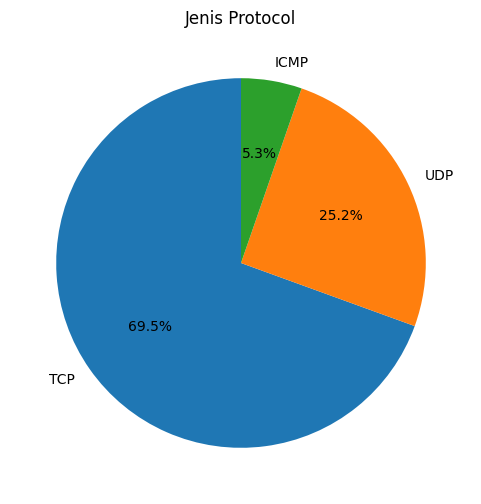

In [15]:
C = df["protocol_type"].value_counts()
print(C)
plt.figure(figsize=(6,6))
plt.pie(C, labels=C.index, autopct='%1.1f%%', startangle=90)
plt.title("Jenis Protocol")
plt.show()

network_segment
A    3217
C    3194
B    3126
Name: count, dtype: int64


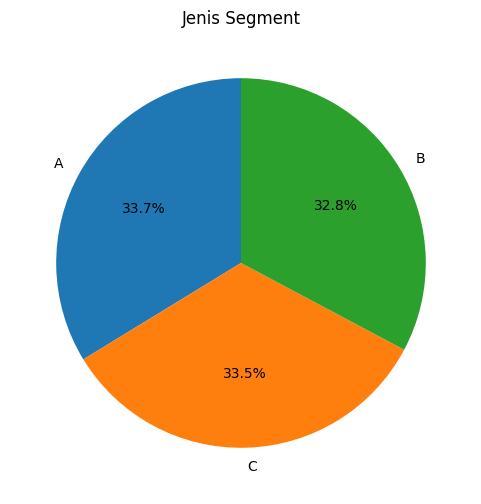

In [16]:
D = df["network_segment"].value_counts()
print(D)
plt.figure(figsize=(6,6))
plt.pie(D, labels=D.index, autopct='%1.1f%%', startangle=90)
plt.title("Jenis Segment")
plt.show()

In [17]:
def atk_type(row):

    if row['login_attempts'] >= 4 and row['failed_logins'] >= 2:
        return "Brute Force"

    if (row['network_packet_size'] >= 600 and row['session_duration'] < 400) or \
       (row['ip_reputation_score'] > 0.5 and row['encryption_used'] in ['DES','AES']):
        return "Malware"

    if row['unusual_time_access'] == 1 or row['browser_type'] in ['Unknown']:
        return "Suspicius"

    if row['attack_detected'] == 0 or (row['failed_logins'] <= 2 and row['ip_reputation_score'] <= 0.5):
        return "Normal"

    return "Suspicius"

df['AttackType'] = df.apply(atk_type, axis=1)
print(df['AttackType'].value_counts())


AttackType
Normal         3636
Brute Force    2593
Malware        1937
Suspicius      1371
Name: count, dtype: int64


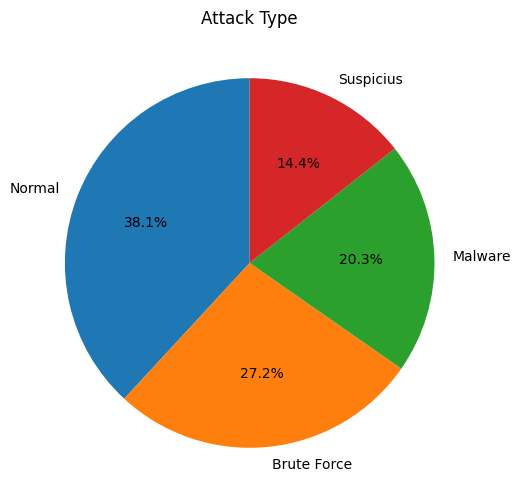

In [18]:
distribusi = df['AttackType'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(distribusi, labels=distribusi.index, autopct='%1.1f%%', startangle=90)
plt.title("Attack Type")
plt.show()

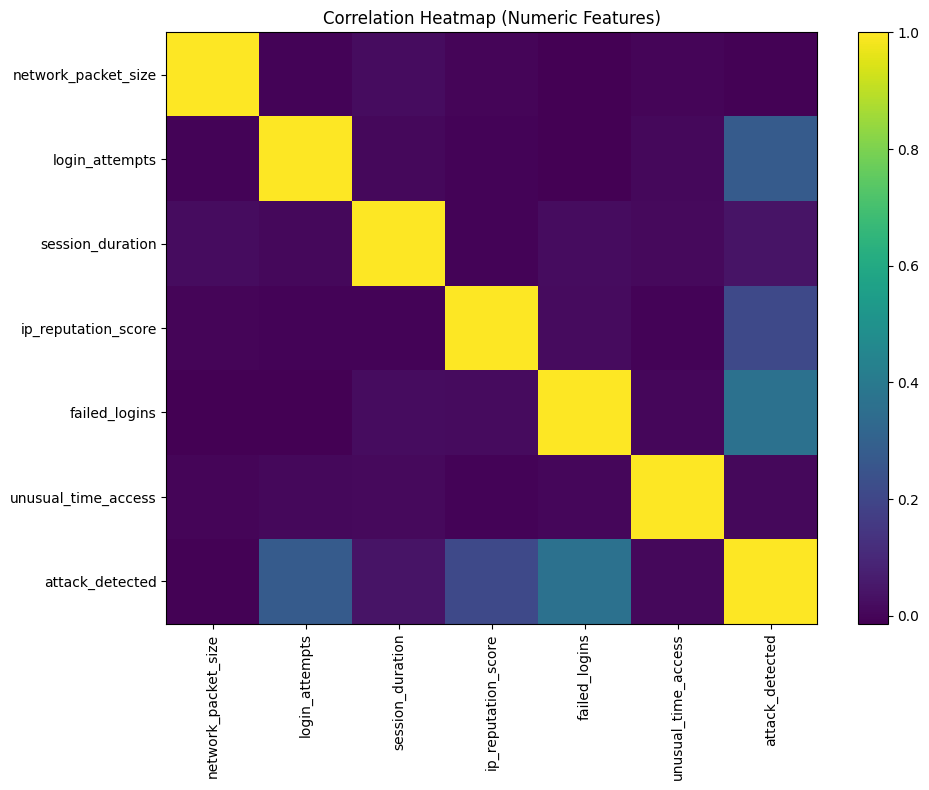

In [19]:
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

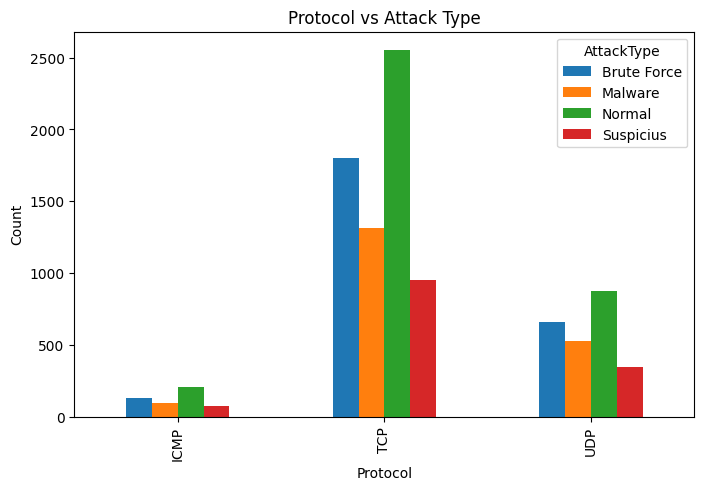

In [20]:
protocol_attack = pd.crosstab(df["protocol_type"], df["AttackType"])

protocol_attack.plot(kind="bar", figsize=(8,5))

plt.title("Protocol vs Attack Type")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()

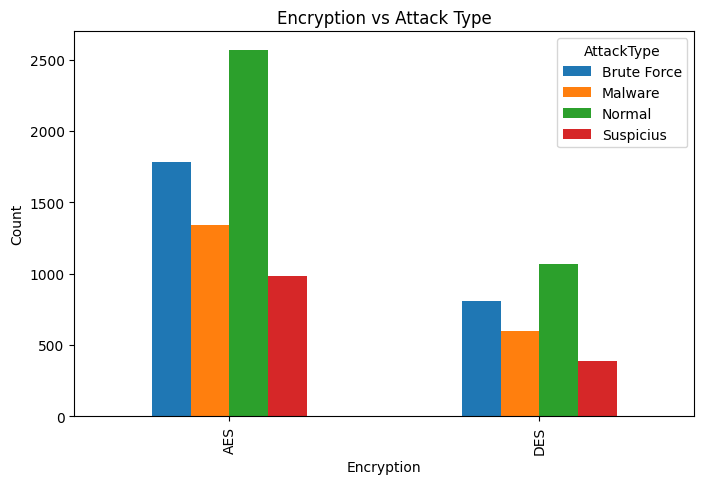

In [21]:
encryption_attack = pd.crosstab(df["encryption_used"], df["AttackType"])

encryption_attack.plot(kind="bar", figsize=(8,5))

plt.title("Encryption vs Attack Type")
plt.xlabel("Encryption")
plt.ylabel("Count")
plt.show()



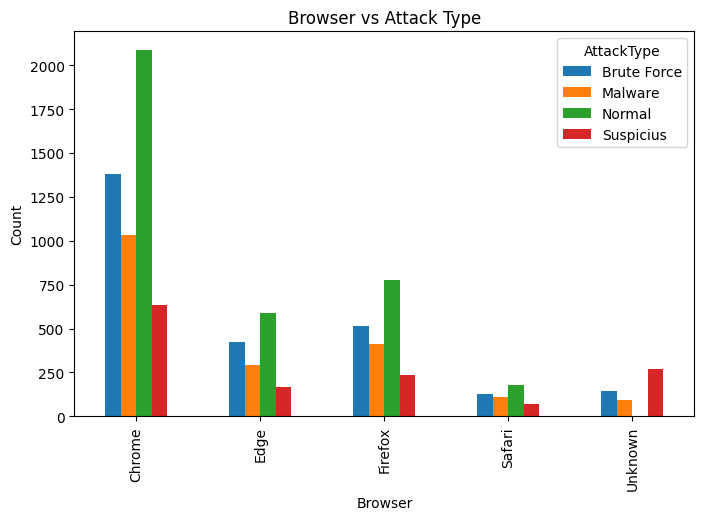

In [22]:
browser_attack = pd.crosstab(df["browser_type"], df["AttackType"])

browser_attack.plot(kind="bar", figsize=(8,5))

plt.title("Browser vs Attack Type")
plt.xlabel("Browser")
plt.ylabel("Count")
plt.show()

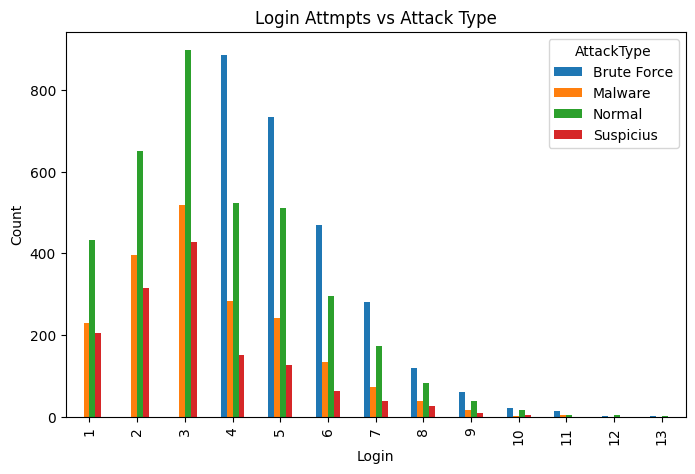

In [23]:
login_attack = pd.crosstab(df["login_attempts"], df["AttackType"])

login_attack.plot(kind="bar", figsize=(8,5))

plt.title("Login Attmpts vs Attack Type")
plt.xlabel("Login")
plt.ylabel("Count")
plt.show()

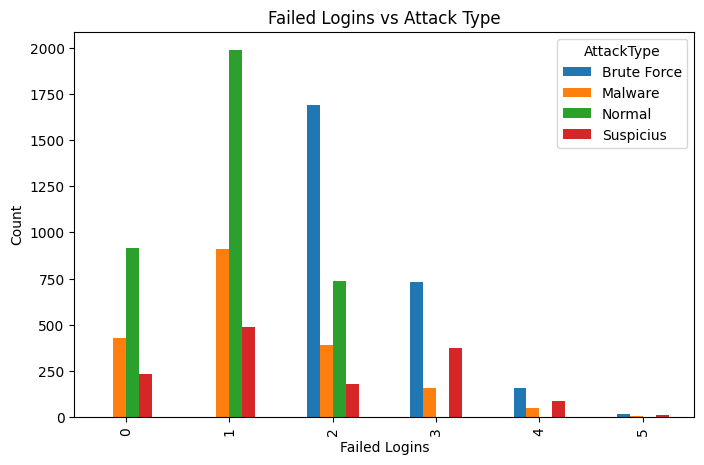

In [24]:
failed_attack = pd.crosstab(df["failed_logins"], df["AttackType"])

failed_attack.plot(kind="bar", figsize=(8,5))

plt.title("Failed Logins vs Attack Type")
plt.xlabel("Failed Logins")
plt.ylabel("Count")
plt.show()

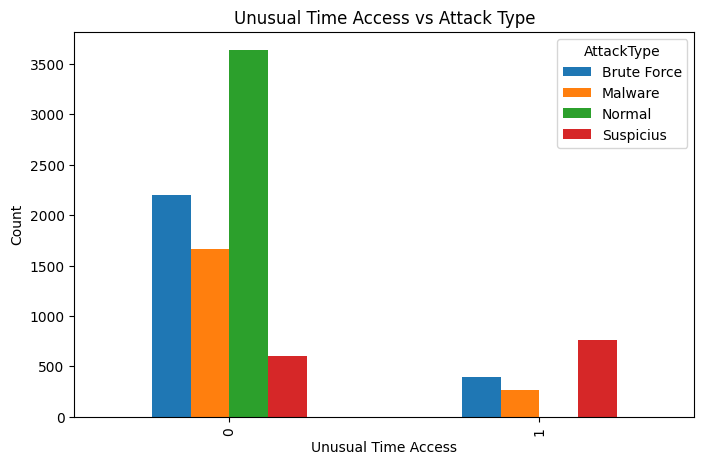

In [25]:
access_attack = pd.crosstab(df["unusual_time_access"], df["AttackType"])

access_attack.plot(kind="bar", figsize=(8,5))

plt.title("Unusual Time Access vs Attack Type")
plt.xlabel("Unusual Time Access")
plt.ylabel("Count")
plt.show()

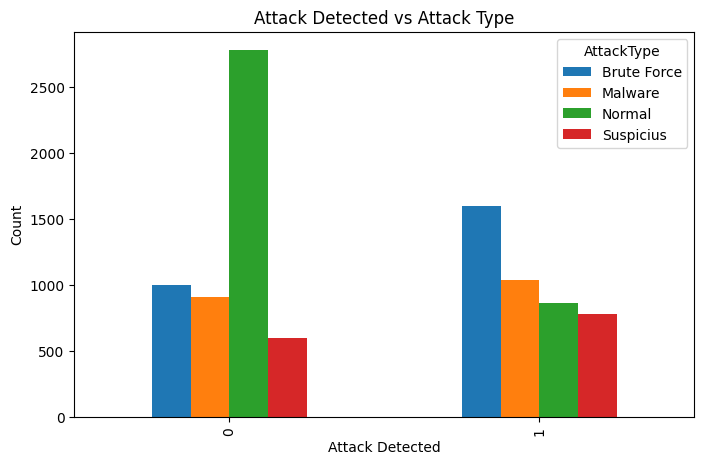

In [26]:
detected_attack = pd.crosstab(df["attack_detected"], df["AttackType"])

detected_attack.plot(kind="bar", figsize=(8,5))

plt.title("Attack Detected vs Attack Type")
plt.xlabel("Attack Detected")
plt.ylabel("Count")
plt.show()

<Figure size 600x500 with 0 Axes>

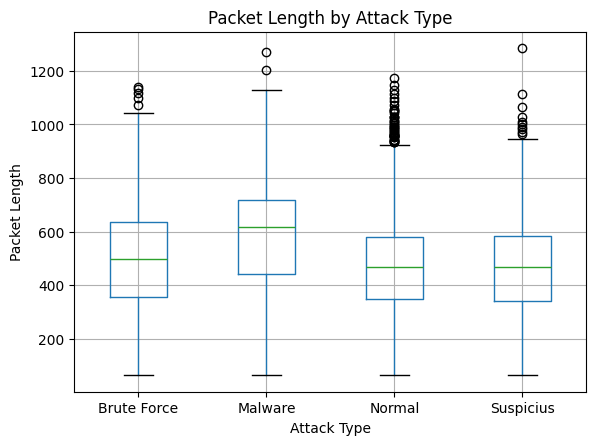

In [27]:
plt.figure(figsize=(6,5))
df.boxplot(column="network_packet_size", by="AttackType")

plt.title("Packet Length by Attack Type")
plt.suptitle("")
plt.xlabel("Attack Type")
plt.ylabel("Packet Length")
plt.show()

In [28]:
df_new = df[['AttackType','network_packet_size','protocol_type','login_attempts'
            ,'session_duration','encryption_used','ip_reputation_score','failed_logins'
            ,'browser_type','unusual_time_access','attack_detected']]

In [29]:
categorical_features = [
    'protocol_type',
    'encryption_used',
    'browser_type',
]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df_new[categorical_features])

encoded_df = pd.DataFrame(encoded_array,
                          columns=encoder.get_feature_names_out(categorical_features),
                          index=df_new.index)

df_encoded = pd.concat([df_new.drop(columns=categorical_features), encoded_df], axis=1)

le = LabelEncoder()
df_encoded['AttackType'] = le.fit_transform(df_new['AttackType'])

print("Mapping Attack Type:", dict(zip(le.classes_, le.transform(le.classes_))))

Mapping Attack Type: {'Brute Force': np.int64(0), 'Malware': np.int64(1), 'Normal': np.int64(2), 'Suspicius': np.int64(3)}


In [30]:
print(df_encoded.head())

   AttackType  network_packet_size  login_attempts  session_duration  \
0           1                  599               4        492.983263   
1           2                  472               3       1557.996461   
2           1                  629               3         75.044262   
3           3                  804               4        601.248835   
4           2                  453               5        532.540888   

   ip_reputation_score  failed_logins  unusual_time_access  attack_detected  \
0             0.606818              1                    0                1   
1             0.301569              0                    0                0   
2             0.739164              2                    0                1   
3             0.123267              0                    0                1   
4             0.054874              1                    0                0   

   protocol_type_ICMP  protocol_type_TCP  protocol_type_UDP  \
0                 0.0        

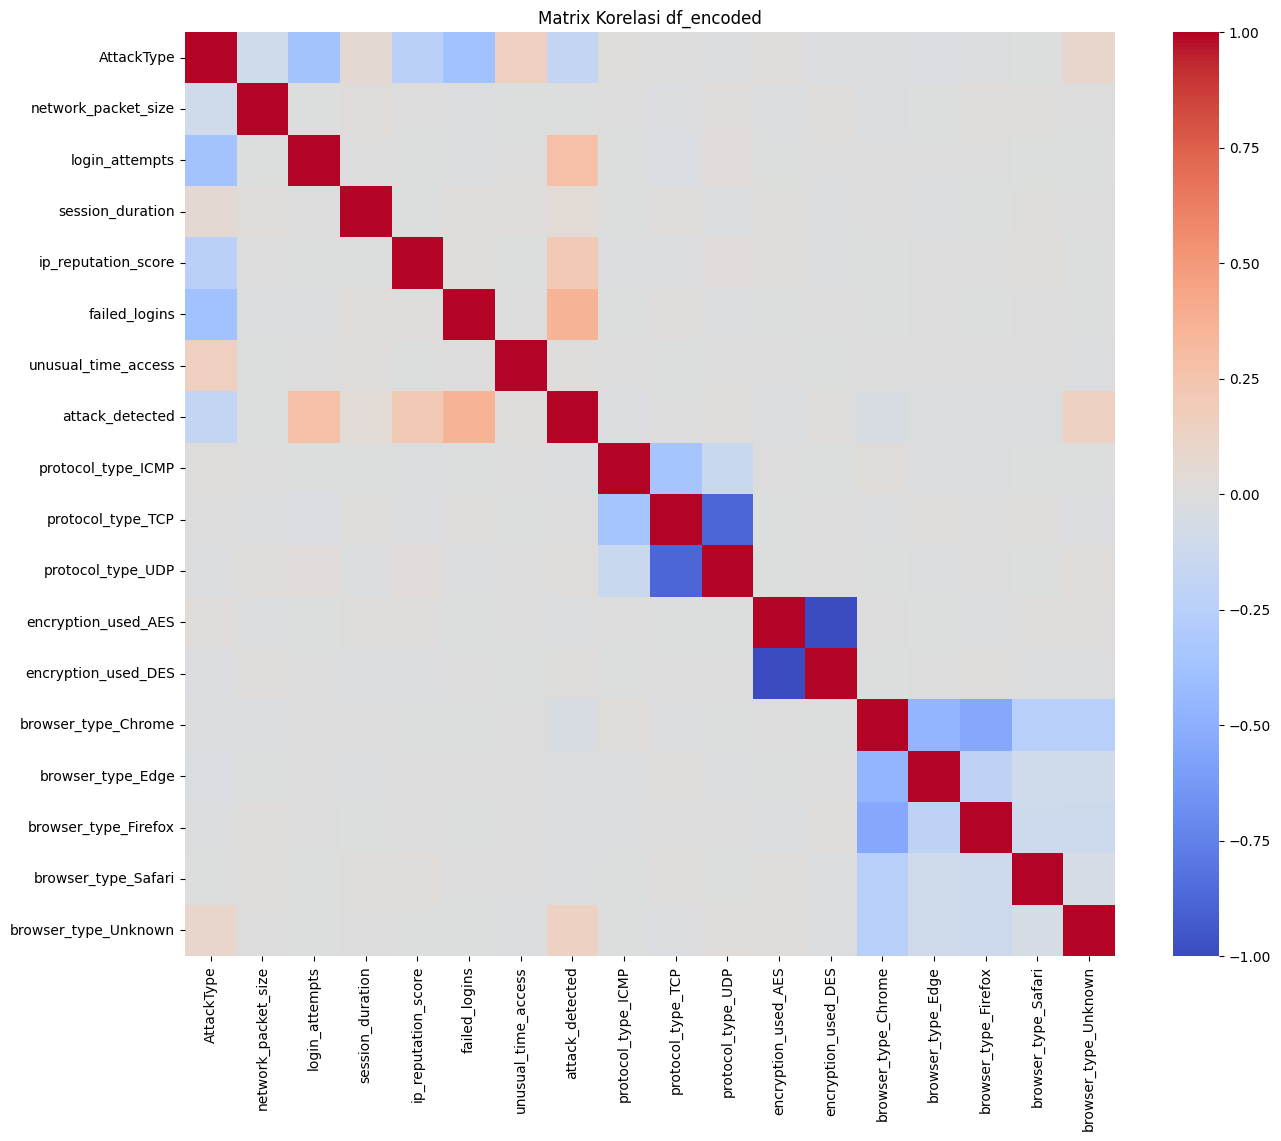

In [31]:
corr_matrix = df_encoded.corr(numeric_only=False)

plt.figure(figsize=(15,12))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0
)
plt.title("Matrix Korelasi df_encoded")
plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       519
           1       1.00      0.99      1.00       388
           2       1.00      1.00      1.00       727
           3       1.00      1.00      1.00       274

    accuracy                           1.00      1908
   macro avg       1.00      1.00      1.00      1908
weighted avg       1.00      1.00      1.00      1908

                 Feature  Importance
4          failed_logins    0.230453
3    ip_reputation_score    0.197411
1         login_attempts    0.188601
5    unusual_time_access    0.130949
0    network_packet_size    0.081164
2       session_duration    0.077933
16  browser_type_Unknown    0.041985
6        attack_detected    0.024947
12   browser_type_Chrome    0.005811
14  browser_type_Firefox    0.003916
13     browser_type_Edge    0.003668
8      protocol_type_TCP    0.002542
9      protocol_type_UDP    0.002534
11   encryption_used_DES    0.002314
10   encry

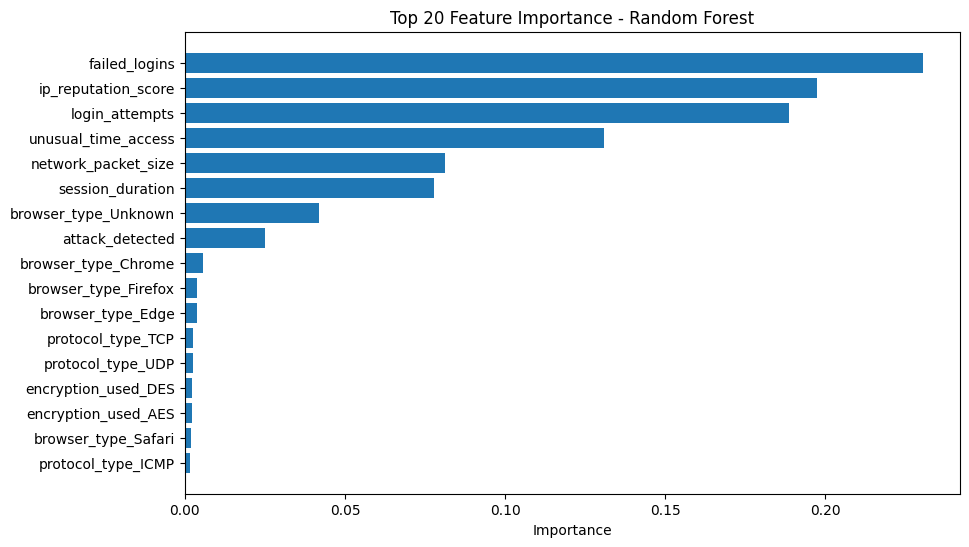

In [ ]:
Xtry = df_encoded.drop(columns=['AttackType'])
ytry = df_encoded['AttackType']

Xtry_train, Xtry_test, ytry_train, ytry_test = train_test_split(Xtry, ytry, test_size=0.2, stratify=ytry, random_state=2)

rftry = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    class_weight='balanced',
    random_state=2
)
rftry.fit(Xtry_train, ytry_train)

ytry_pred = rftry.predict(Xtry_test)
print(classification_report(ytry_test, ytry_pred))

importances = rftry.feature_importances_
feat_names = Xtry.columns

feat_imp = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

print(feat_imp.head(20))

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'][:20], feat_imp['Importance'][:20])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

In [ ]:
X = df_encoded[['network_packet_size','login_attempts','failed_logins','unusual_time_access',
                'encryption_used_AES','encryption_used_DES','encryption_used_None','browser_type_Chrome',
                'browser_type_Edge','browser_type_Firefox','browser_type_Safari','browser_type_Unknown',
                'protocol_type_ICMP','protocol_type_TCP','protocol_type_UDP','ip_reputation_score']]
y = df_encoded['AttackType']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [None, 2, 5, 10],
    'min_samples_leaf': [None, 1, 2, 4]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='accuracy')

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred))

In [40]:
X = df_encoded[['encryption_used_AES','encryption_used_DES','browser_type_Chrome',
                'browser_type_Edge','browser_type_Firefox','browser_type_Safari','browser_type_Unknown',
                'protocol_type_ICMP','protocol_type_TCP','protocol_type_UDP','login_attempts','failed_logins',
                'network_packet_size','session_duration','ip_reputation_score']]
y = df_encoded['AttackType']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    min_samples_leaf=2,
    min_samples_split=2
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       519
           1       1.00      1.00      1.00       388
           2       0.84      1.00      0.91       727
           3       0.99      0.51      0.68       274

    accuracy                           0.93      1908
   macro avg       0.96      0.88      0.90      1908
weighted avg       0.94      0.93      0.92      1908



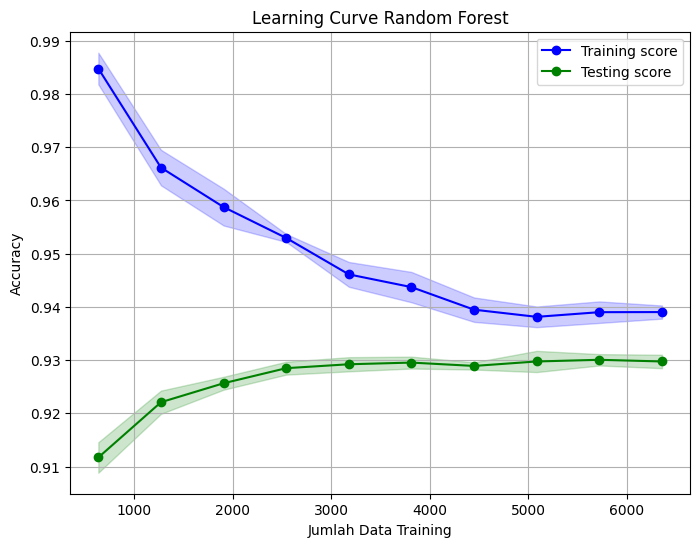

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    rf, X, y, cv=3, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=2
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Testing score")

plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2, color="blue")
plt.fill_between(train_sizes, test_mean-test_std, test_mean+test_std, alpha=0.2, color="green")

plt.title("Learning Curve Random Forest")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()


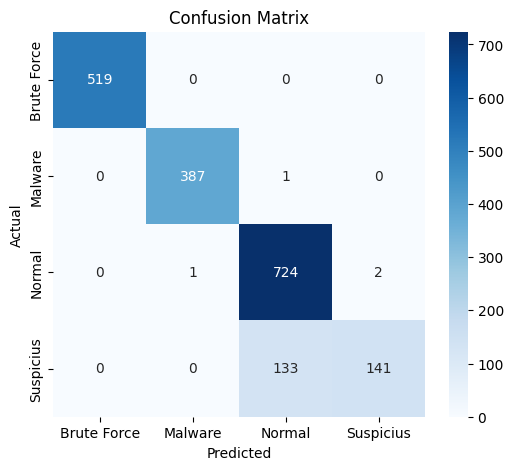

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
Xh = df_encoded[['encryption_used_AES','encryption_used_DES','browser_type_Chrome',
                'browser_type_Edge','browser_type_Firefox','browser_type_Safari','browser_type_Unknown',
                'protocol_type_ICMP','protocol_type_TCP','protocol_type_UDP','login_attempts','failed_logins',
                'network_packet_size','session_duration','ip_reputation_score']]
yh = df_encoded['AttackType']

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    Xh, yh, test_size=0.2, stratify=yh, random_state=42
)

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 8, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(Xh_train, yh_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
yh_pred = best_model.predict(Xh_test)
print(classification_report(yh_test, yh_pred))

Fitting 3 folds for each of 108 candidates, totalling 324 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:25:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.8}
Best Score: 0.9311836413684625
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       519
           1       0.99      1.00      1.00       388
           2       0.84      1.00      0.91       727
           3       1.00      0.51      0.67       274

    accuracy                           0.93      1908
   macro avg       0.96      0.88      0.90      1908
weighted avg       0.94      0.93      0.92      1908



In [33]:
Xg = df_encoded[['encryption_used_AES','encryption_used_DES','browser_type_Chrome',
                'browser_type_Edge','browser_type_Firefox','browser_type_Safari','browser_type_Unknown',
                'protocol_type_ICMP','protocol_type_TCP','protocol_type_UDP','login_attempts','failed_logins',
                'network_packet_size','session_duration','ip_reputation_score']]
yg = df_encoded['AttackType']

Xg_train, Xg_test, yg_train, yg_test = train_test_split(Xg, yg, test_size=0.2, stratify=yg, random_state=42)

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(Xg_train, yg_train)

yg_pred = xgb.predict(Xg_test)

print(classification_report(yg_test, yg_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:54:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       519
           1       0.99      1.00      1.00       388
           2       0.84      1.00      0.91       727
           3       1.00      0.51      0.67       274

    accuracy                           0.93      1908
   macro avg       0.96      0.88      0.90      1908
weighted avg       0.94      0.93      0.92      1908



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:01:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:01:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:01:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:01:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, ite

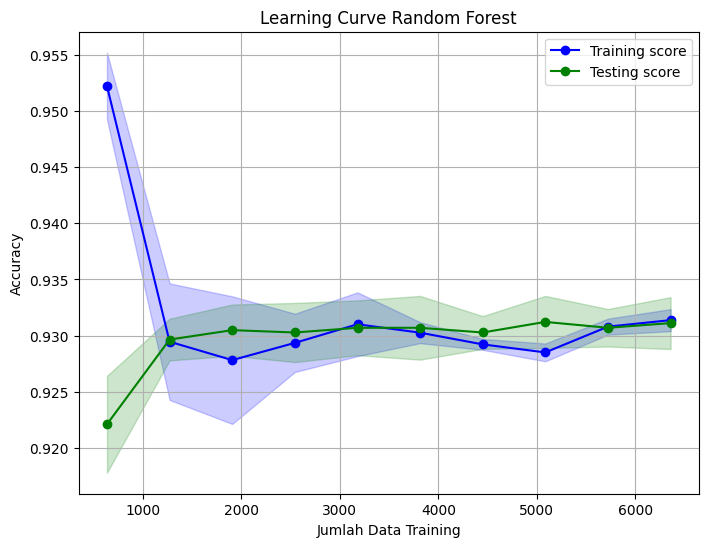

In [36]:
train_sizesx, train_scoresx, test_scoresx = learning_curve(
    xgb, Xg, yg, cv=3, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_meanx = np.mean(train_scoresx, axis=1)
train_stdx = np.std(train_scoresx, axis=1)
test_meanx = np.mean(test_scoresx, axis=1)
test_stdx = np.std(test_scoresx, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizesx, train_meanx, 'o-', color="blue", label="Training score")
plt.plot(train_sizesx, test_meanx, 'o-', color="green", label="Testing score")

plt.fill_between(train_sizesx, train_meanx-train_stdx, train_meanx+train_stdx, alpha=0.2, color="blue")
plt.fill_between(train_sizesx, test_meanx-test_stdx, test_meanx+test_stdx, alpha=0.2, color="green")

plt.title("Learning Curve Random Forest")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid(True)
plt.show()

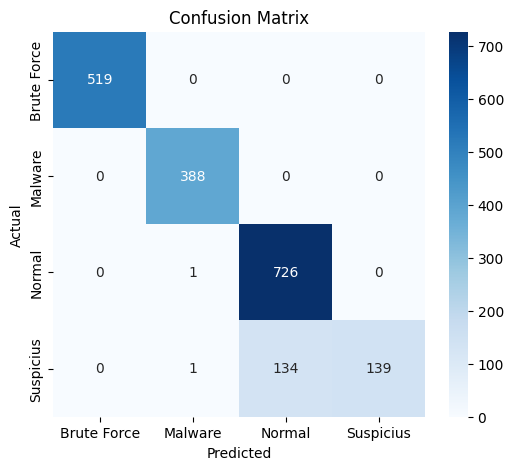

In [37]:
cm = confusion_matrix(yg_test, yg_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [41]:
numeric_features = ['login_attempts','failed_logins','session_duration',
                    'network_packet_size','ip_reputation_score']
categorical_features = ['encryption_used','browser_type','protocol_type']

#y_train = ['AttackType']
X_train_raw = df_new.loc[y_train.index, categorical_features + numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num','passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=2,
        min_samples_leaf=42,
        min_samples_split=2
    ))
])

pipeline.fit(X_train_raw, y_train)

X_test_raw = df_new.loc[y_test.index, categorical_features + numeric_features]
y_pred = pipeline.predict(X_test_raw)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

pipeline = {
    "pipeline": pipeline,
    "accuracy": accuracy
}
joblib.dump(pipeline, "rf_pipeline.joblib")

Accuracy: 0.9166666666666666


['rf_pipeline.joblib']

In [ ]:
def dataset():
    pipeline_load = joblib.load("/content/rf_pipeline.joblib")

    Enkripsi = input("Masukkan Jenis Enkripsi (AES/DES) : ")
    Browser = input("Masukkan Jenis Browser (Chrome/Firefox/Edge/Safari/Unknown) : ")
    Protokol = input("Masukkan Jenis Protokol (ICMP/TCP/UDP): ")
    Login = int(input("Berapa Banyak Login : "))
    Login_failed = int(input("Berapa Banyak Login Yang Salah : "))
    Waktu_janggal = int(input("Apakah Ada Waktu Login Janggal? (1/0) : "))
    Paket = int(input("Berapa Ukuran Paket Data : "))
    Ip_reputation = float(input("Reputasi IP : "))

    input_data = pd.DataFrame([[Enkripsi, Browser, Protokol, Login,
                                  Login_failed, Waktu_janggal, Paket, Ip_reputation]],
                              columns=['encryption_used', 'browser_type', 'protocol_type', 'login_attempts',
                                       'failed_logins', 'unusual_time_access', 'network_packet_size', 'ip_reputation_score'])

    preds = pipeline_load.predict(input_data)

    attack_mapping = {
    0: "Brute force",
    1: "Malware",
    2: "Normal",
    3: "Suspicious"
}

    pred_label = preds[0]


    hasil = attack_mapping.get(pred_label, "Unknown")

    print("\n=== HASIL ANALISIS ===")
    print(f"Jenis Enkripsi          : {Enkripsi}")
    print(f"Jenis Protokol          : {Protokol}")
    print(f"Jumlah Login            : {Login} kali")
    print(f"Jumlah Login Gagal      : {Login_failed} kali")
    print(f"Waktu Akses Tidak Biasa : {Waktu_janggal}")
    print(f"Ukuran Paket Data       : {Paket}")
    print(f"Reputasi IP             : {Ip_reputation}")
    print(f"Hasil Analisis          : {hasil}")

    return hasil


while True:
    print("\n=== MENU ===")
    print("1. Analisis Menggunakan Model Random Forest")
    print("0. Keluar")

    pilihan = input("Masukkan pilihan: ")

    if pilihan == "1":
        dataset()
    elif pilihan == "0":
        print("Program selesai.")
        break
    else:
        print("Pilihan tidak valid.")

In [44]:
def dataset():
    pipeline_load = joblib.load("/content/rf_pipeline.joblib")
    pipeline = pipeline_load['pipeline']
    accuracy = pipeline_load['accuracy']

    Enkripsi = input("Masukkan Jenis Enkripsi (AES/DES) : ")
    Browser = input("Masukkan Jenis Browser (Chrome/Firefox/Edge/Safari/Unknown) : ")
    Protokol = input("Masukkan Jenis Protokol (ICMP/TCP/UDP): ")
    Login = int(input("Berapa Banyak Login : "))
    Login_failed = int(input("Berapa Banyak Login Yang Salah : "))
    Waktu_sesi = float(input("Lama Waktu Sesi (Detik) : "))
    Paket = int(input("Berapa Ukuran Paket Data : "))
    Ip_reputation = float(input("Reputasi IP : "))

    input_data = pd.DataFrame([[Enkripsi, Browser, Protokol, Login,
                                  Login_failed, Waktu_sesi, Paket, Ip_reputation]],
                              columns=['encryption_used', 'browser_type', 'protocol_type', 'login_attempts',
                                       'failed_logins', 'session_duration', 'network_packet_size', 'ip_reputation_score'])

    probs = pipeline.predict_proba(input_data)[0]

    attack_mapping = {
        0: "Brute force",
        1: "Malware",
        2: "Normal",
        3: "Suspicious"
    }

    pred_label = probs.argmax()
    hasil = attack_mapping.get(pred_label, "Unknown")

    print("\n=== HASIL ANALISIS ===")
    print(f"Jenis Enkripsi          : {Enkripsi}")
    print(f"Jenis Protokol          : {Protokol}")
    print(f"Jumlah Login            : {Login} kali")
    print(f"Jumlah Login Gagal      : {Login_failed} kali")
    print(f"Waktu Akses Tidak Biasa : {Waktu_sesi}")
    print(f"Ukuran Paket Data       : {Paket}")
    print(f"Reputasi IP             : {Ip_reputation}")
    print(f"Hasil Analisis          : {hasil} ({probs[pred_label]*100:.2f}%)")
    print(f'Akurasi Prediksi Model  : {accuracy*100:.2f}%')

    print("\n=== Probabilitas Semua Label ===")
    for i, p in enumerate(probs):
        print(f"{attack_mapping[i]}: {p*100:.2f}%")

    return hasil



while True:
    print("\n=== MENU ===")
    print("1. Analisis Menggunakan Model Random Forest")
    print("0. Keluar")

    pilihan = input("Masukkan pilihan: ")

    if pilihan == "1":
        dataset()
    elif pilihan == "0":
        print("Program selesai.")
        break
    else:
        print("Pilihan tidak valid.")



=== MENU ===
1. Analisis Menggunakan Model Random Forest
0. Keluar
Masukkan pilihan: 1
Masukkan Jenis Enkripsi (AES/DES) : DES
Masukkan Jenis Browser (Chrome/Firefox/Edge/Safari/Unknown) : Firefox
Masukkan Jenis Protokol (ICMP/TCP/UDP): UDP
Berapa Banyak Login : 3
Berapa Banyak Login Yang Salah : 1
Lama Waktu Sesi (Detik) : 689
Berapa Ukuran Paket Data : 754
Reputasi IP : 0.56

=== HASIL ANALISIS ===
Jenis Enkripsi          : DES
Jenis Protokol          : UDP
Jumlah Login            : 3 kali
Jumlah Login Gagal      : 1 kali
Waktu Akses Tidak Biasa : 689.0
Ukuran Paket Data       : 754
Reputasi IP             : 0.56
Hasil Analisis          : Malware (79.82%)
Akurasi Prediksi Model  : 91.67%

=== Probabilitas Semua Label ===
Brute force: 1.62%
Malware: 79.82%
Normal: 9.23%
Suspicious: 9.33%

=== MENU ===
1. Analisis Menggunakan Model Random Forest
0. Keluar


KeyboardInterrupt: Interrupted by user